In [1]:
import pandas as pd
import numpy as np


In [2]:
imoveis_df = pd.read_csv("csv files/imoveisTraining.csv")
imoveis_df.head(10)

,Bairro,Numero de quartos,Metros quadrados,Vagas de Garagem,Numero de Banheiros,Preço
0,Recanto do Salto,4,319,2,5,3890000
1,Jardim Nações Unidas,2,45,1,1,155000
2,Jardim São Jorge,3,159,2,4,1715000
3,Marumbi,4,191,4,4,1390000
4,Gleba Fazenda Palhano,2,62,1,2,615000
5,Petrópolis,4,610,1,2,1100000
6,Centro,3,96,1,2,500000
7,Jardim Morumbi,3,196,2,5,1500000
8,Brasília,2,70,1,2,330000
9,Catuai,3,80,2,1,280000


<p style="text-align: center;">Com os dados preparados, minha primeira escolha de modelo para resolver esse problema de previsão de preços de imóveis foi um algoritmo de regressão linear, mais especificamente a regressão Ridge por conta da regularização do coeficiente L2, que permite a redução de overfitting e trabalha melhor com colinearidade. Por conta de ser um modelo mais simples ele será minha baseline para testar outros modelos. </p>

<p style="text-align: center;">Com isso, decidi as features a serem utilizadas. Com base em outras soluções e também para efeitos de teste, utilizei todas as features de teste iniciais dos dados, que são número de quartos, metros quadrados, vagas de garagem e numero de banheiros. Depois, eu testarei com mais uma feature que será o bairro, e utilizarei one hot encoding para isso. </p>

In [42]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split, GridSearchCV
from time import process_time

np.random.seed(76000)
X_original = imoveis_df.drop(["Preço", "Bairro"], axis=1)
y_original = imoveis_df["Preço"]

X_train_original, X_test_original, y_train_original, y_test_original = train_test_split(X_original, y_original, test_size = 0.2)
clf_ridge_original = Ridge()

start = process_time()
clf_ridge_original.fit(X_train_original, y_train_original)
end = process_time()

y_preds_ridge_original = clf_ridge_original.predict(X_test_original)

r2_score_ridge_original = r2_score(y_test_original, y_preds_ridge_original)
mae_score_ridge_original = mean_absolute_error(y_test_original, y_preds_ridge_original)
mse_score_ridge_original = mean_squared_error(y_test_original, y_preds_ridge_original)


print(f"R2 score Ridge: {r2_score_ridge_original}")
print(f"MAE score Ridge: {mae_score_ridge_original}")
print(f"MSE score Ridge: {mse_score_ridge_original}")
print(f"Com tempo de {end - start} segundos")



R2 score Ridge: 0.5942910618106965
MAE score Ridge: 405706.4696074236
MSE score Ridge: 534527987282.2959
Com tempo de 0.0 segundos


### Tentando melhorar o modelo utilizando alfas diferentes. 

In [56]:

param_grid_ridge_original = {
    'alpha': [0.001, 0.01, 0.1, 1.0, 10, 100]
}

start = process_time()
grid_search_ridge_original = GridSearchCV(clf_ridge_original, param_grid_ridge_original, cv=5, verbose = 2, n_jobs=-1)
grid_search_ridge_original.fit(X_train_original, y_train_original)
end = process_time()


y_preds_ridge_original_optimal = grid_search_ridge_original.predict(X_test_original)

r2_score_ridge_original_optimal = r2_score(y_test_original, y_preds_ridge_original)
mae_score_ridge_original_optimal = mean_absolute_error(y_test_original, y_preds_ridge_original_optimal)
mse_score_ridge_original_optimal = mean_squared_error(y_test_original, y_preds_ridge_original_optimal)


print(f"R2 score Ridge: {r2_score_ridge_original_optimal}")
print(f"MAE score Ridge: {mae_score_ridge_original_optimal}")
print(f"MSE score Ridge: {mse_score_ridge_original_optimal}")
print(f"Com tempo de {end - start} segundos")

print(f"Melhor alpha: {grid_search_ridge_original.best_params_}")


Fitting 5 folds for each of 6 candidates, totalling 30 fits
R2 score Ridge: 0.5942910618106965
MAE score Ridge: 405708.36287551274
MSE score Ridge: 534527744583.9208
Com tempo de 0.09375 segundos
Melhor alpha: {'alpha': 0.001}


### Como não funcionou bem sem a feature de bairros, irei fazer o one hot encoding e tentar novamente 

In [58]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

np.random.seed(76000)
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output = False).set_output(transform='pandas')
bairros = imoveis_df[["Bairro"]]
ohe_transform = ohe.fit_transform(bairros)

X_ohe = pd.concat([imoveis_df, ohe_transform], axis=1).drop(["Preço", "Bairro"], axis=1)
y_ohe = imoveis_df["Preço"]
X_train_ohe, X_test_ohe, y_train_ohe, y_test_ohe = train_test_split(X_ohe, y_ohe, test_size = 0.2)

clf_ridge_ohe = Ridge()

start = process_time()
clf_ridge_ohe.fit(X_train_ohe, y_train_ohe)
end = process_time()

y_preds_ridge_ohe = clf_ridge_ohe.predict(X_test_ohe) 


r2_score_ridge_ohe = r2_score(y_test_ohe, y_preds_ridge_ohe)
mae_score_ridge_ohe = mean_absolute_error(y_test_ohe, y_preds_ridge_ohe)
mse_score_ridge_ohe = mean_squared_error(y_test_ohe, y_preds_ridge_ohe)



print(f"R2 score Ridge: {r2_score_ridge_ohe}")
print(f"MAE score Ridge: {mae_score_ridge_ohe}")
print(f"MSE score Ridge: {mse_score_ridge_ohe}")
print(f"Com tempo de {end - start} segundos")


R2 score Ridge: 0.7371049737245436
MAE score Ridge: 309282.00401484617
MSE score Ridge: 346368383917.57886
Com tempo de 1.453125 segundos


<p style="text-align: center;">Podemos perceber que houve um aumento muito grande no R2 score, com 0.73, indicando que 73% da diferença entre nossos dados podem ser explicadas. Um aumento considerável de quando não havia a feature de bairro. Com isso, há espaço para melhora, então irei mudar de algoritmos de regressão linear para utilizar um algoritmo de ensemble: Random Forest. O Random Forest para regressão é mais robusto, não varia tanto com outliers que nem o Ridge, portanto eu acredito que possa performar melhor</p>

In [15]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


X = imoveis_df.drop(["Preço", "Bairro"], axis=1)
y = imoveis_df["Preço"]

np.random.seed(76000)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)


clf_random_forest = RandomForestRegressor()

start = process_time()
clf_random_forest.fit(X_train, y_train)
end = process_time()

y_preds_rf = clf_random_forest.predict(X_test)

r2_score_rf = r2_score(y_test, y_preds_rf)
mae_score_rf = mean_absolute_error(y_test, y_preds_rf)
mse_score_rf = mean_squared_error(y_test, y_preds_rf)


print(f"R2 score Random Forest: {r2_score_rf}")
print(f"MAE score Random Forest: {mae_score_rf}")
print(f"MSE score Random Forest: {mse_score_rf}")
print(f"Com tempo de {end - start} segundos")
#clf_random_forest.score(X_test, y_test)

R2 score Random Forest: 0.7988346361451371
MAE score Random Forest: 276198.9953775506
MSE score Random Forest: 331201772250.51886
Com tempo de 1.03125 segundos


In [17]:
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30],
    'min_samples_split': [2, 5, 10],
}

start = process_time()
grid_search = GridSearchCV(clf_random_forest, param_grid_rf, cv=5, verbose = 2, n_jobs=-1)
grid_search.fit(X_train, y_train)
end = process_time()

y_preds_rf = grid_search.predict(X_test)

r2_score_rf = r2_score(y_test, y_preds_rf)
mae_score_rf = mean_absolute_error(y_test, y_preds_rf)
mse_score_rf = mean_squared_error(y_test, y_preds_rf)


print(f"R2 score Random Forest: {r2_score_rf}")
print(f"MAE score Random Forest: {mae_score_rf}")
print(f"MSE score Random Forest: {mse_score_rf}")
print(f"Com tempo de {end - start} segundos")
print(grid_search.best_params_)

Fitting 5 folds for each of 27 candidates, totalling 135 fits
R2 score Random Forest: 0.8005612846488783
MAE score Random Forest: 279515.538099053
MSE score Random Forest: 328358991398.317
Com tempo de 26.59375 segundos
{'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 100}


In [18]:

comparisonDict = {"Predição: ": y_preds_rf,
               "Valor Real": y_test}


comparisonDf = pd.DataFrame(comparisonDict)
X_test["Preço"] = y_test
X_test["Predição"] = y_preds_rf.round(3)
#y_preds_rf, X_test, y_test
#comparisonDf
X_test[:50]

,Numero de quartos,Metros quadrados,Vagas de Garagem,Numero de Banheiros,Preço,Predição
1993,3,76,4,1,250000,277975.157
13616,3,318,4,5,3490000,2348169.643
479,4,580,3,5,2800000,3100425.385
10123,3,118,1,2,620000,395107.405
7500,3,113,3,1,700000,617755.389
21169,4,421,5,5,2400000,2755795.238
360,3,84,1,2,862000,473458.326
21421,4,140,2,4,370000,823052.139
12351,3,117,2,2,740000,658070.165
499,2,44,1,1,145000,188571.179


### Tentando utilizar o Ridge agora

### Tentando denovo com one hot encoding

### Grid Search para achar os melhores hiperparametros

In [4]:
param_grid_ridge = {
    "alpha": np.linspace(0, 10, 11)
}
np.random.seed(100)

grid_search_ridge = GridSearchCV(clf_ridge, param_grid_ridge, cv=5, verbose = 2, n_jobs=-1)
grid_search_ridge.fit(X_train, y_train)

y_preds_ridge = grid_search_ridge.predict(X_test)

r2_score_ridge = r2_score(y_test, y_preds_ridge)
mae_score_ridge = mean_absolute_error(y_test, y_preds_ridge)
mse_score_ridge = mean_squared_error(y_test, y_preds_ridge)



r2_score_ridge = r2_score(y_test, y_preds_ridge)
mae_score_ridge = mean_absolute_error(y_test, y_preds_ridge)
mse_score_ridge = mean_squared_error(y_test, y_preds_ridge)

print(f"R2 score Ridge: {r2_score_ridge}")
print(f"MAE score Ridge: {mae_score_ridge}")
print(f"MSE score Ridge: {mse_score_ridge}")
print(f"Best score Ridge: {grid_search_ridge.best_params_}")


Fitting 5 folds for each of 11 candidates, totalling 55 fits
R2 score Ridge: 0.7358853778987866
MAE score Ridge: 313209.967108036
MSE score Ridge: 403372476334.3173
Best score Ridge: {'alpha': np.float64(1.0)}


In [6]:
param_grid_ridge = {
    "alpha": np.linspace(0, 1, 50)
}
np.random.seed(100)

grid_search_ridge = GridSearchCV(clf_ridge, param_grid_ridge, cv=5, verbose = 2, n_jobs=-1)
grid_search_ridge.fit(X_train, y_train)

y_preds_ridge = grid_search_ridge.predict(X_test)

r2_score_ridge = r2_score(y_test, y_preds_ridge)
mae_score_ridge = mean_absolute_error(y_test, y_preds_ridge)
mse_score_ridge = mean_squared_error(y_test, y_preds_ridge)



r2_score_ridge = r2_score(y_test, y_preds_ridge)
mae_score_ridge = mean_absolute_error(y_test, y_preds_ridge)
mse_score_ridge = mean_squared_error(y_test, y_preds_ridge)

print(f"R2 score Ridge: {r2_score_ridge}")
print(f"MAE score Ridge: {mae_score_ridge}")
print(f"MSE score Ridge: {mse_score_ridge}")
print(f"Best score Ridge: {grid_search_ridge.best_params_}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
R2 score Ridge: 0.7368282860305841
MAE score Ridge: 313041.3532727555
MSE score Ridge: 401932407681.34753
Best score Ridge: {'alpha': np.float64(0.5306122448979591)}


### Resultado melhor que o que fora aplicado anteriormente. Tentarei com random forest agora

In [7]:
from sklearn.ensemble import RandomForestRegressor

np.random.seed(100)

clf_random_forest = RandomForestRegressor()
clf_random_forest.fit(X_train, y_train)

y_preds_rf = clf_random_forest.predict(X_test)

r2_score_rf = r2_score(y_test, y_preds_rf)
mae_score_rf = mean_absolute_error(y_test, y_preds_rf)
mse_score_rf = mean_squared_error(y_test, y_preds_rf)


print(f"R2 score Random Forest: {r2_score_rf}")
print(f"MAE score Random Forest: {mae_score_rf}")
print(f"MSE score Random Forest: {mse_score_rf}")

R2 score Random Forest: 0.9184814213627027
MAE score Random Forest: 147136.73617793305
MSE score Random Forest: 124500304718.37825


In [33]:
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30],
    'min_samples_split': [2, 5, 10],
}


grid_search_rf = GridSearchCV(clf_random_forest, param_grid_rf, cv=5, verbose = 4, n_jobs=-1)
grid_search_rf.fit(X_train, y_train)

y_preds_rf = grid_search_rf.predict(X_test)

r2_score_rf = r2_score(y_test, y_preds_rf)
mae_score_rf = mean_absolute_error(y_test, y_preds_rf)
mse_score_rf = mean_squared_error(y_test, y_preds_rf)

r2_score_rf = r2_score(y_test, y_preds_rf)
mae_score_rf = mean_absolute_error(y_test, y_preds_rf)
mse_score_rf = mean_squared_error(y_test, y_preds_rf)

print(f"R2 score Random Forest: {r2_score_rf}")
print(f"MAE score Random Forest: {mae_score_rf}")
print(f"MSE score Random Forest: {mse_score_rf}")
print(f"Best score Random Forest: {grid_search_rf.best_params_}")

Fitting 5 folds for each of 27 candidates, totalling 135 fits
R2 score Random Forest: 0.7358853778987866
MAE score Random Forest: 313209.967108036
MSE score Random Forest: 403372476334.3173
Best score Random Forest: {'max_depth': 30, 'min_samples_split': 2, 'n_estimators': 100}


In [34]:
print(f"R2 score Random Forest: {r2_score_rf}")
print(f"MAE score Random Forest: {mae_score_rf}")
print(f"MSE score Random Forest: {mse_score_rf}")
print(f"Best score Random Forest: {grid_search_rf.best_params_}")

R2 score Random Forest: 0.9160434798985757
MAE score Random Forest: 157388.22328483997
MSE score Random Forest: 128223682385.6933
Best score Random Forest: {'max_depth': 30, 'min_samples_split': 2, 'n_estimators': 100}


### Vendo os melhores features

In [11]:
#clf_random_forest.feature_importances_

import matplotlib.pyplot as plt
import seaborn as sns

importances = clf_random_forest.feature_importances_

# Cria um DataFrame para visualizar
feat_imp_df = pd.DataFrame({"Feature": X_train.columns, "Importância": importances})
feat_imp_df = feat_imp_df.sort_values(by="Importância", ascending=False)

# Gráfico de Importância das Features
plt.figure(figsize=(10, 5))
sns.barplot(x=feat_imp_df["Importância"], y=feat_imp_df["Feature"])
plt.title("Importância das Features - Random Forest")
plt.show()

ValueError: All arrays must be of the same length

C:\Users\Andrei\AppData\Local\Temp\ipykernel_904\2824400613.py:8: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test)


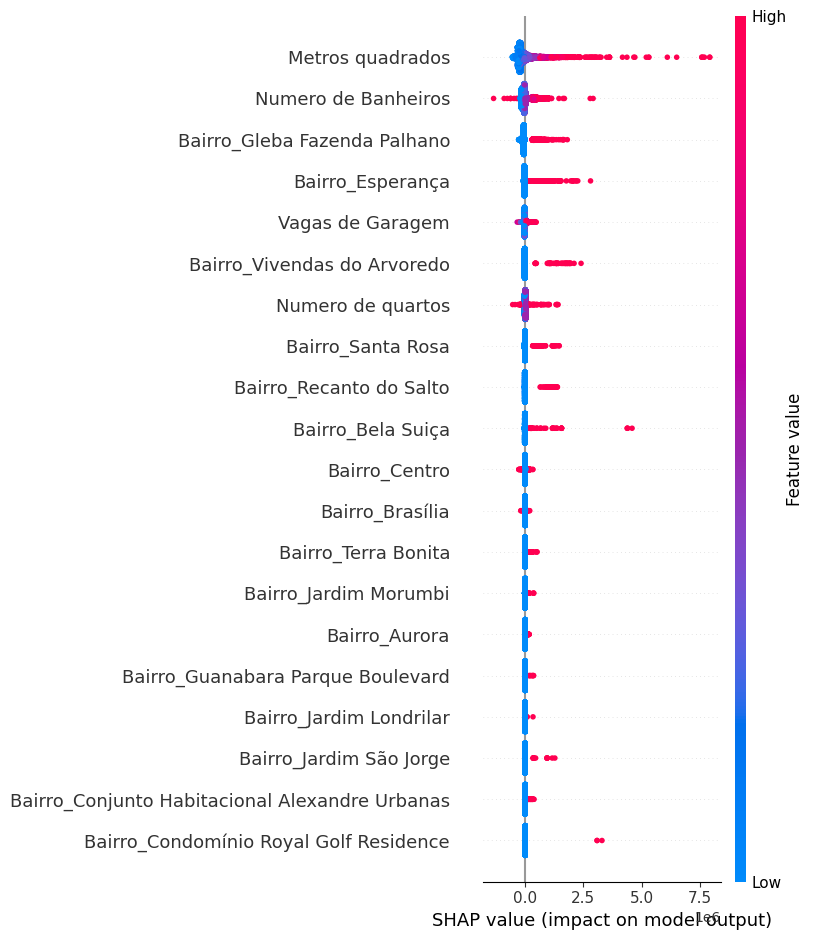

In [13]:
import shap

# Cria um objeto SHAP explainer
explainer = shap.Explainer(clf_random_forest, X_train)
shap_values = explainer(X_test)

# Gráfico de Importância Global das Features
shap.summary_plot(shap_values, X_test)

In [63]:
np.random.seed(100)
X_view = imoveis_df.drop(["Preço"], axis=1)
y_view = imoveis_df["Preço"]

X_train_view, X_test_view, y_train_view, y_test_view = train_test_split(X_view, y_view, test_size = 0.2)


X_test_view["Preço"] = y_test_view
X_test_view["Predição"] = y_preds_rf.round(0)
#y_preds_rf, X_test, y_test
#comparisonDf


centro_view = X_test_view[X_test_view["Bairro"] == "Centro"]
gleba_view = X_test_view[X_test_view["Bairro"] == "Gleba Fazenda Palhano"]
bela_suica_view = X_test_view[X_test_view["Bairro"] == "Bela Suiça"]
bela_suica_view_new = bela_suica_view[bela_suica_view["Predição"] == 5687584.0]
#X_test_view[:50]
#centro_view[:50]
#gleba_view[:50]
bela_suica_view_new[:50]

,Bairro,Numero de quartos,Metros quadrados,Vagas de Garagem,Numero de Banheiros,Preço,Predição
20810,Bela Suiça,4,427,4,5,5980000,5687584.0
18164,Bela Suiça,4,427,4,5,8500000,5687584.0
16742,Bela Suiça,4,427,4,5,6000000,5687584.0
14489,Bela Suiça,4,427,4,5,5990000,5687584.0
13568,Bela Suiça,4,427,4,5,6050000,5687584.0
18632,Bela Suiça,4,427,4,5,5980000,5687584.0
